In [140]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [141]:
import numpy as np
np.NaN=np.nan
import vectorbt as vbt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tqdm 
from tabulate import tabulate
import warnings

warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) 
pd.set_option('display.max_colwidth', None)


# Split_OHLCV

In [ ]:
import pandas as pd
import os

# Input and output paths
INPUT_FILE = 'input_ohlcv/all_ohlcv.csv'
OUTPUT_DIR = 'split_ohlcv_data'

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Reading {INPUT_FILE}...")
# Read the CSV with multi-level headers
df = pd.read_csv(INPUT_FILE, header=[0, 1], index_col=0)

print(f"Data shape: {df.shape}")
print(f"Columns (first 5): {df.columns[:5].tolist()}")

# Extract unique attributes from the second level of headers
attributes = df.columns.get_level_values(1).unique().tolist()
print(f"\nFound attributes: {attributes}")

# Split and save each attribute
for attr in attributes:
    print(f"\nProcessing '{attr}'...")
    
    # Extract all columns with this attribute
    attr_df = df.xs(attr, level=1, axis=1)
    
    # Save to file
    output_file = os.path.join(OUTPUT_DIR, f'all_{attr}.csv')
    attr_df.to_csv(output_file)
    
    print(f"  ✅ Saved {output_file}")
    print(f"     Shape: {attr_df.shape}")
    print(f"     Columns: {list(attr_df.columns[:3])}..." if len(attr_df.columns) > 3 else f"     Columns: {list(attr_df.columns)}")

# Also save the complete file to split_ohlcv_data for consistency
complete_output = os.path.join(OUTPUT_DIR, 'all_ohlcv.csv')
df.to_csv(complete_output)
print(f"\n✅ Also saved complete file to {complete_output}")

print("\n🎉 All files split successfully!")


In [142]:
# Input file
INPUT_WEIGHTS = 'input_weights/WEIGHTS.csv'

# Input Parameters
INITIAL_CAPITAL = 100000
# Date range will be derived from weights.csv
# no need to set these manually
START_DATE = None
END_DATE = None

In [143]:
try:
    print("\n--- 1. Processing Multi-Level File (All OHLCV) ---")
    # CRITICAL FIX: Read with header=[0, 1] and index_col=0 to preserve structure
    df_all = pd.read_csv('split_ohlcv_data/all_ohlcv.csv', header=[0, 1], index_col=0)
    
    # Convert Index to Datetime and Normalize (Remove Time)
    df_all.index = pd.to_datetime(df_all.index)
    df_all.index = df_all.index.normalize()
    
    # Clip/Slice the data between TRADING_START_DATE and END_DATE
    df_all_clipped = df_all.loc[START_DATE:END_DATE]
    
    # Save the clipped version
    # This preserves the 2-row header structure and contains only the trading period
    df_all_clipped.to_csv('src/all_ohlcv_clipped.csv')
    
    print("✅ Saved: all_ohlcv_clipped.csv (Clipped to trading period)")
    print(f"   Data range: {df_all_clipped.index[0]} to {df_all_clipped.index[-1]}")
except FileNotFoundError as e:
    print(f"❌ Error: File not found. {e}")
except Exception as e:
    print(f"❌ An error occurred: {e}")


--- 1. Processing Multi-Level File (All OHLCV) ---
✅ Saved: all_ohlcv_clipped.csv (Clipped to trading period)
   Data range: 2020-01-01 00:00:00 to 2026-01-16 00:00:00


# BACKTESTER

In [144]:
from typing import Tuple

class Strategy():
    def __init__(self):
        self.signalsData = pd.read_csv(
            INPUT_WEIGHTS, #replace with your file path
            na_values=['nan', 'NaN', ''],
            keep_default_na=True
        )
        self.signalsData.set_index(self.signalsData.columns[0], inplace=True)

    def get_signals(self, tradingState: dict) -> Tuple[list, str]:
        if self.signalsData.empty:
            raise ValueError(f'INPUT_WEIGHTS file {INPUT_WEIGHTS} has no rows; please populate weights.')

        trader_idx = tradingState['traderData']
        if trader_idx >= len(self.signalsData):
            raise IndexError(
                f'No signal for index {trader_idx}; only {len(self.signalsData)} rows in {INPUT_WEIGHTS}. '
                f'Ensure the weights file covers the whole backtest date range.'
            )

        signal = self.signalsData.iloc[trader_idx]
        tickers = signal.index.tolist()
        signal = pd.Series(signal.values, index=tickers)
        traderData = tradingState['traderData'] + 1
        return signal, traderData


In [145]:
class Backtester:
    def __init__(self, data: pd.DataFrame, initial_value: float, start_date):
        self.data = data
        self.initialvalue = initial_value
        self.portfolio_value = initial_value
        self.cash = initial_value
        self.investment = 0.0
        self.current_index = 1
        tickers = data.columns.get_level_values(0).unique()
        self.positions = pd.Series(0, index=tickers)
        self.all_positions = pd.DataFrame(columns=tickers)
        self.tradingState = {}
        self.all_signals = pd.DataFrame(columns=tickers)
        self.startdate = start_date

    def calculate_positions(self, signal: pd.Series, value, open=True) -> pd.Series:
        # --- Checks (Unchanged) ---
        if (signal < 0).any():
            raise ValueError(f'For timestamp {self.data.index[self.current_index]}, signal contains negative values: {signal[signal < 0]}')
        if not isinstance(signal, pd.Series):
            raise TypeError(f'For timestamp {self.data.index[self.current_index]}, signal must be a pandas Series, got {type(signal)}')
        if abs(signal).sum() - 1 > 1e-6:
            raise ValueError(f'For timestamp {self.data.index[self.current_index]} the sum of the abs(signals) must not be greater than 1, got {abs(signal).sum()}')

        prices = (
            self.data.xs('open', level=1, axis=1).iloc[self.current_index]
            if open
            else self.data.xs('close', level=1, axis=1).iloc[self.current_index]
        )
        prices = prices.reindex(signal.index)

        aligned_positions = self.positions.reindex(signal.index).fillna(0)

        nan_index = signal.isna()

        value -= (aligned_positions[nan_index] * prices[nan_index]).sum()

        float_shares = (signal.replace(0, np.nan) * value) / prices.replace(0, np.nan)
        float_shares = float_shares.replace([np.inf, -np.inf], 0).fillna(0)

        new_positions = pd.Series(0, index=float_shares.index, dtype=int)
        longs = float_shares > 0
        shorts = float_shares < 0

        new_positions[longs] = np.floor(float_shares[longs]).astype(int)
        new_positions[shorts] = np.ceil(float_shares[shorts]).astype(int)

        new_positions[nan_index] = aligned_positions[nan_index]

        return new_positions

    def calculate_cash(self, positions: pd.Series, open=True) -> float:
        index = self.current_index
        price = self.data.xs('open', level=1, axis=1).iloc[index] if open else self.data.xs('close', level=1, axis=1).iloc[index]
        return self.portfolio_value - (abs(positions) * price).sum()

    def update_investment(self, positions: pd.Series, new_day=False) -> float:
        index = self.current_index
        price1 = self.data.xs('close', level=1, axis=1).iloc[index - 1] if new_day else self.data.xs('open', level=1, axis=1).iloc[index]
        price2 = self.data.xs('open', level=1, axis=1).iloc[index] if new_day else self.data.xs('close', level=1, axis=1).iloc[index]
        return (positions * (price2 - price1)).sum() + self.investment

    def run(self):
        """
        Fast NumPy-based execution loop, while keeping the existing Strategy() pipeline
        (reads weights row-by-row from INPUT_WEIGHTS) and the same outputs.

        Semantics preserved from calculate_positions():
        - NaN weight => keep existing shares
        - 0 weight  => set shares to 0
        - weights apply to *available* value after reserving NaN holdings
        """
        output_signals_path = 'results/signals.csv'
        output_positions_path = 'results/positions.csv'

        import os
        if not os.path.exists('results'):
            os.makedirs('results')
            print("Created 'results' directory for output files.")

        print("Starting backtest (NumPy engine)...")
        strategy = Strategy()

        tickers = self.data.columns.get_level_values(0).unique()
        n_assets = len(tickers)
        n_steps = len(self.data.index)

        open_df = self.data.xs('open', level=1, axis=1).loc[:, tickers]
        close_df = self.data.xs('close', level=1, axis=1).loc[:, tickers]
        open_px = open_df.to_numpy(dtype=float)
        close_px = close_df.to_numpy(dtype=float)

        pos_array = np.zeros(n_assets, dtype=np.int64)
        cash = float(self.initialvalue)

        all_pos_history = np.zeros((n_steps, n_assets), dtype=np.int64)
        all_sig_history = np.full((n_steps, n_assets), np.nan, dtype=float)

        traderData = 0
        for i in tqdm.tqdm(range(0, n_steps)):
            ts = self.data.index[i]

            # Keep Strategy() contract: pull one weight row per step from the weights CSV
            self.tradingState = {
                'investment': self.investment,
                'cash': self.cash,
                'current_timestamp': ts,
                'traderData': traderData,
                'positions': self.positions,
            }
            signal, traderData = strategy.get_signals(self.tradingState)
            if signal is None:
                raise ValueError(f'For timestamp {ts}, signal is None')
            signal = signal.reindex(tickers)
            weights_row = signal.to_numpy(dtype=float)
            all_sig_history[i] = weights_row

            # --- Execution at Open[i], valuation at Close[i] ---
            curr_open = open_px[i]
            curr_close = close_px[i]

            # Mark-to-market at open before trading
            portfolio_value_open = cash + float(np.sum(pos_array * curr_open))

            update_mask = ~np.isnan(weights_row)
            if np.any(update_mask):
                # Validate long-only weights constraint (same idea as calculate_positions)
                if np.nansum(np.abs(weights_row)) - 1 > 1e-6:
                    raise ValueError(
                        f'For timestamp {ts} the sum of abs(weights) must not be greater than 1, got {np.nansum(np.abs(weights_row))}'
                    )
                if np.nanmin(weights_row) < -1e-12:
                    raise ValueError(f'For timestamp {ts}, weights contain negative values.')

                # Reserve value for holdings that are not being updated today (NaN => keep)
                reserved_value = float(np.sum(pos_array[~update_mask] * curr_open[~update_mask]))
                available_value = portfolio_value_open - reserved_value
                if available_value < 0:
                    available_value = 0.0

                target_weights = np.nan_to_num(weights_row[update_mask], nan=0.0)
                target_prices = curr_open[update_mask]

                # Allocate only the available value across updated tickers
                dollars = target_weights * available_value

                with np.errstate(divide='ignore', invalid='ignore'):
                    shares = np.floor(np.divide(dollars, target_prices, out=np.zeros_like(dollars), where=target_prices != 0.0))
                    shares = np.nan_to_num(shares, nan=0.0, posinf=0.0, neginf=0.0).astype(np.int64)

                pos_array[update_mask] = shares

            # Cash after trades at open
            cash = portfolio_value_open - float(np.sum(pos_array * curr_open))

            # End-of-day valuation at close
            investment_close = float(np.sum(pos_array * curr_close))
            portfolio_value_close = cash + investment_close

            all_pos_history[i] = pos_array
            self.current_index = i
            self.cash = cash
            self.investment = investment_close
            self.portfolio_value = portfolio_value_close

        # Store outputs as DataFrames (same shape as before)
        self.positions = pd.Series(pos_array, index=tickers)
        self.all_positions = pd.DataFrame(all_pos_history, index=self.data.index, columns=tickers)
        self.all_signals = pd.DataFrame(all_sig_history, index=self.data.index, columns=tickers)

        try:
            self.all_signals.to_csv(output_signals_path)
            self.all_positions.to_csv(output_positions_path)
            tqdm.tqdm.write(f"\n--- Checkpoint Saved progress to CSV files. ---")
        except Exception as e:
            tqdm.tqdm.write(f"\n--- Could not save checkpoint. Reason: {e} ---")

    def vectorbt_run(self):
        if self.startdate is None or pd.isna(self.startdate):
            filtered_positions = self.all_positions
        else:
            filtered_positions = self.all_positions[self.all_positions.index >= self.startdate]
            if filtered_positions.empty:
                filtered_positions = self.all_positions

        open_prices = self.data.xs('open', level=1, axis=1).loc[filtered_positions.index, filtered_positions.columns]
        close_prices = self.data.xs('close', level=1, axis=1).loc[filtered_positions.index, filtered_positions.columns]

        positions_to_use = filtered_positions
        order_size = positions_to_use.diff()
        order_size.iloc[0]=positions_to_use.iloc[0]
        order_size=order_size.astype(int)


        order_size = order_size.reindex(index=open_prices.index, columns=open_prices.columns).fillna(0)
        order_size = order_size.mask(order_size == 0)

        portfolio = vbt.Portfolio.from_orders(
            close=close_prices,
            size=order_size,
            price=open_prices,
            init_cash=self.initialvalue,
            freq='1D',
            cash_sharing=True,
            call_seq='auto',
            log=True,
        )
        print(f"Initial Amount= {portfolio.init_cash}")

        benchmark_df = pd.read_csv('src/benchmark.csv', index_col=0, parse_dates=True)
        benchmark_df = benchmark_df[START_DATE:END_DATE]

        start_price = benchmark_df['close'].iloc[0]
        end_price = benchmark_df['close'].iloc[-1]
        benchmark_return = ((end_price - start_price) / start_price) * 100

        stats_eq = portfolio.stats()
        stats_df = stats_eq.to_frame(name='Value').reset_index()
        stats_df.columns = ['Metric', 'Value']

        stats_df = stats_df[stats_df['Metric'] != 'Benchmark Return [%]'].reset_index(drop=True)

        benchmark_row = pd.DataFrame({
            'Metric': ['Benchmark Return [%]'],
            'Value': [benchmark_return]
        })

        stats_df_top = stats_df.iloc[:6]
        stats_df_bottom = stats_df.iloc[6:]
        stats_df = pd.concat([stats_df_top, benchmark_row, stats_df_bottom], ignore_index=True)

        portfolio.assets().to_csv('results/assets.csv')
        portfolio.orders.records_readable.to_csv('results/log.csv')

        df = pd.concat([portfolio.value(), portfolio.asset_value(), portfolio.cash()], axis=1)
        df.columns = ['portfolio', 'investment', 'cash']
        df.to_csv('results/portfolio.csv')

        display(stats_df)
        return portfolio


In [146]:
# Derive START_DATE and END_DATE from weights CSV
weights_df = pd.read_csv(INPUT_WEIGHTS, index_col=0, parse_dates=True)
START_DATE = weights_df.index.min()
END_DATE = weights_df.index.max()

data = pd.read_csv(
    'src/all_ohlcv_clipped.csv',
    index_col=0, parse_dates=True, header=[0, 1]
)

if pd.isna(START_DATE) or pd.isna(END_DATE):
    START_DATE = data.index.min()
    END_DATE = data.index.max()

# Filter data to match weights date range
data = data.loc[START_DATE:END_DATE]

backtester = Backtester(data, INITIAL_CAPITAL, START_DATE)
backtester.run()
print(f"Final Portfolio value= {backtester.portfolio_value}")

pf = backtester.vectorbt_run()


Starting backtest (NumPy engine)...


100%|██████████| 1502/1502 [00:00<00:00, 10993.82it/s]


--- Checkpoint Saved progress to CSV files. ---
Final Portfolio value= 214370.22425961998
Initial Amount= 100000.0


,Metric,Value
0,Start,2020-01-02 00:00:00
1,End,2026-01-16 00:00:00
2,Period,1502 days 00:00:00
3,Start Value,100000.0
4,End Value,214370.22426
5,Total Return [%],114.370224
6,Benchmark Return [%],119.198471
7,Max Gross Exposure [%],99.974968
8,Total Fees Paid,0.0
9,Max Drawdown [%],44.058017


In [147]:
import plotly.graph_objects as go
import plotly.io as pio
benchmark_df = pd.read_csv('src/benchmark.csv', index_col=0, parse_dates=True)
benchmark_df=benchmark_df[START_DATE:END_DATE]#HERE ALSO IF UPDATED DATE IN "backtest()"
no_of_stocks = 100000 / benchmark_df['close'].iloc[0]
benchmark_df['close'] = benchmark_df['close'] * no_of_stocks
stats_eq = pf.stats()
eq_curve = pf.value()
eq_curve=eq_curve[START_DATE:END_DATE]
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=eq_curve.index,
    y=eq_curve.values,
    mode='lines',
    name='Portfolio',
    line=dict(color='blue', width=3)
))
fig.add_trace(go.Scatter(
    x=benchmark_df.index,
    y=benchmark_df.iloc[:, 0],  # assumes benchmark is in first column
    mode='lines',
    name='Benchmark',
    line=dict(color='green', width=2)
))
fig.update_layout(
    title='Portfolio vs Benchmark',
    xaxis_title='Date',
    yaxis_title='Value',
    template='plotly_white'
)

fig.show()



In [148]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

returns = eq_curve.pct_change().fillna(0)
returns=returns[START_DATE:END_DATE]
cum_max = eq_curve.cummax()
drawdown = (eq_curve - cum_max) / cum_max
mean_ret = returns.mean()
median_ret = returns.median()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Daily Returns', 'Drawdown Curve'))
fig.add_trace(
    go.Histogram(
        x=returns,
        nbinsx=50,
        marker_color='orange',
        marker_line_color='white',
        marker_line_width=1,
        opacity=0.8,
        name='Returns'
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=drawdown.index,
        y=drawdown.values,
        mode='lines',
        line=dict(color='red', width=2),
        name='Drawdown'
    ),
    row=1, col=2
)
fig.update_xaxes(
    title_text='Return',
    row=1, col=1,
    nticks=20,
    showgrid=True
)
fig.update_yaxes(
    title_text='Frequency',
    row=1, col=1,
    showgrid=True
)
fig.update_xaxes(
    title_text='Date',
    row=1, col=2,
    showgrid=False
)
fig.update_yaxes(
    title_text='Drawdown',
    row=1, col=2,
    showgrid=True
)
fig.update_layout(
    title_text='Returns Distribution & Drawdown',
    bargap=0.1,               
    template='plotly_white',
    showlegend=False,
    width=900,
    height=400
)

fig.show()


---------------Successfully loaded 'results/signals.csv'---------------
Number of STOCKS BOUGHT with TIME


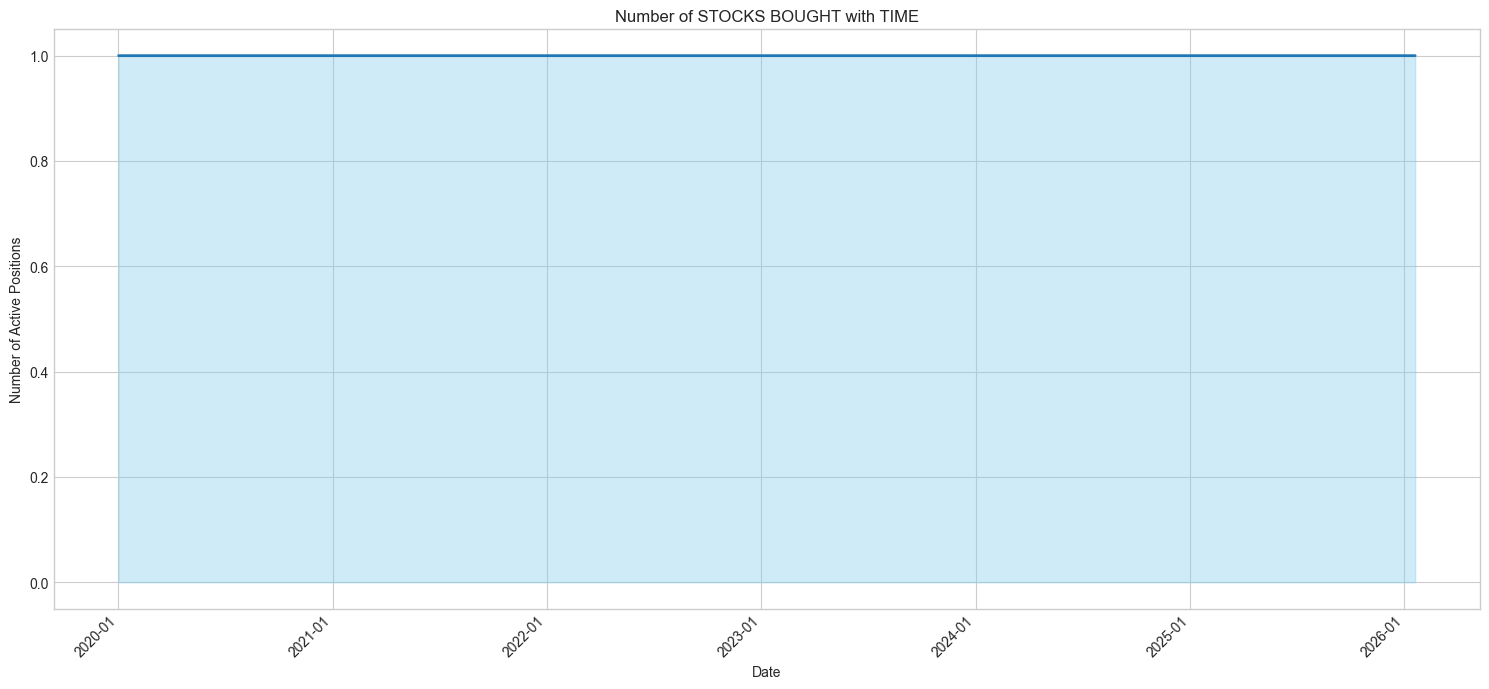

Percentage of CAPITAL INVESTED with TIME


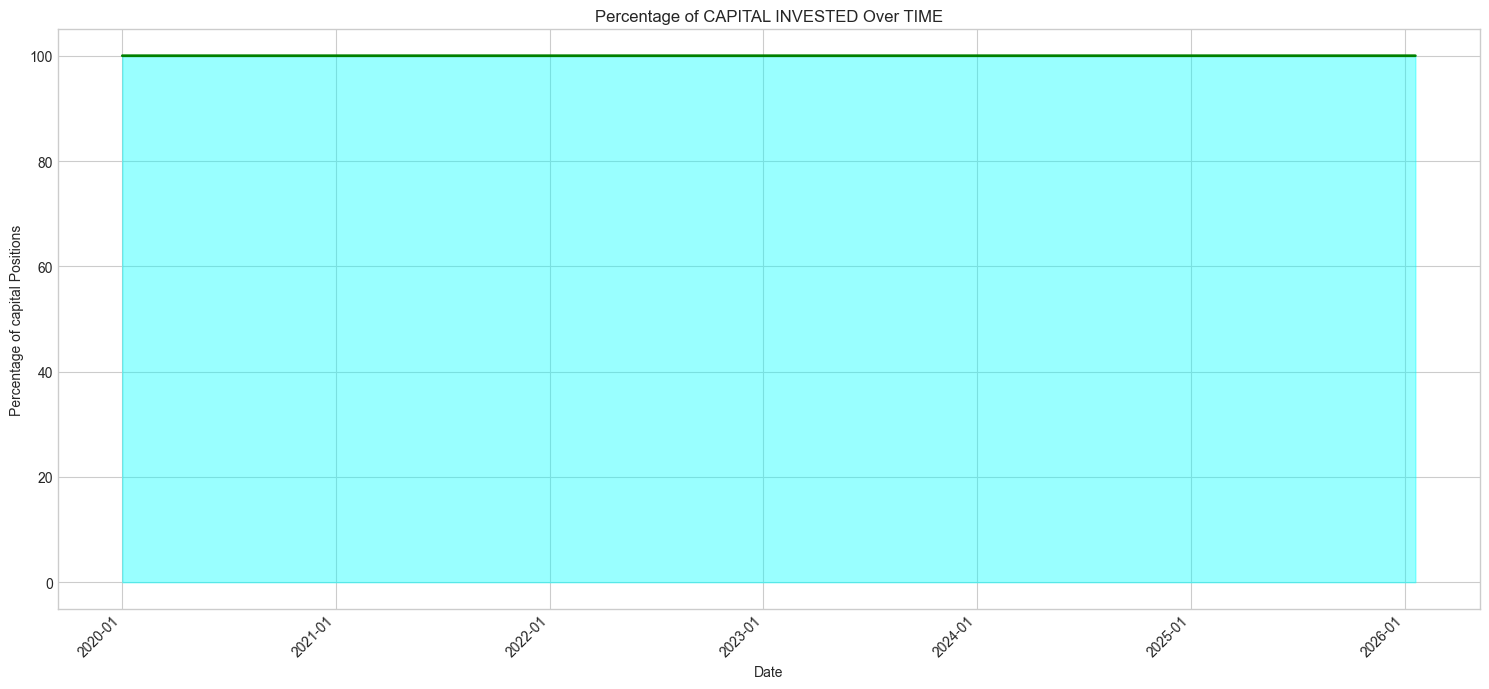

In [149]:

weights_df = pd.read_csv(INPUT_WEIGHTS, index_col=0, parse_dates=True)
print("---------------Successfully loaded 'results/signals.csv'---------------")

print("Number of STOCKS BOUGHT with TIME")
weights_df=weights_df.ffill()
weights_df=weights_df[START_DATE:END_DATE]
invested_stocks_count = (weights_df > 0).sum(axis=1)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))
invested_stocks_count.plot(
    ax=ax,
    title='Number of STOCKS BOUGHT with TIME',
    xlabel='Date',
    ylabel='Number of Active Positions',
    lw=2
)
ax.fill_between(
        invested_stocks_count.index, 
        invested_stocks_count.values, 
        step='post', 
        color='skyblue', 
        alpha=0.4 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()



print("Percentage of CAPITAL INVESTED with TIME")
weights_df = pd.read_csv(INPUT_WEIGHTS, index_col=0, parse_dates=True)
weights_df=weights_df*100
weights_df=weights_df.ffill()
weights_df=weights_df[START_DATE:END_DATE]
invested_stocks_count = weights_df.sum(axis=1)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))
invested_stocks_count.plot(
    ax=ax,
    title='Percentage of CAPITAL INVESTED Over TIME',
    xlabel='Date',
    ylabel='Percentage of capital Positions',
    lw=2,
    drawstyle='steps-post',
    color='green'
)
ax.fill_between(
        invested_stocks_count.index, 
        invested_stocks_count.values, 
        step='post', 
        color='cyan', 
        alpha=0.4 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()
